Código adaptado de:

[1] Mark Liu, Learn Generative AI with PyTorch [(Github link)](https://github.com/markhliu/DGAI). [capítulo 3]

# Laboratório 1: GANs (dados 2D)

# Importações

In [1]:
!pip install torchinfo

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision.transforms import ToTensor # Importa a transformação ToTensor, que converte imagens PIL ou NumPy arrays em tensores PyTorch
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Etapas Envolvidas no Treinamento de GANs


# 1. Preparando os Dados de Treinamento

## 1.1 Um Conjunto de Treinamento que Forma uma Curva de Crescimento Exponencial

In [4]:
torch.manual_seed(0)                              # Fixa a semente do gerador de números aleatórios para resultados reprodutíveis.
observations = 2048                               # Número de amostras (linhas) a serem geradas para o conjunto de treinamento.
train_data = torch.zeros((observations, 2))       # Cria um tensor (N, 2) de zeros em float32: coluna 0 será x, coluna 1 será y.
train_data[:, 0] = 50 * torch.rand(observations)  # Preenche x com valores ~ U[0, 50).
train_data[:, 1] = 1.08 ** train_data[:, 0]       # Define y = 1.08^x.

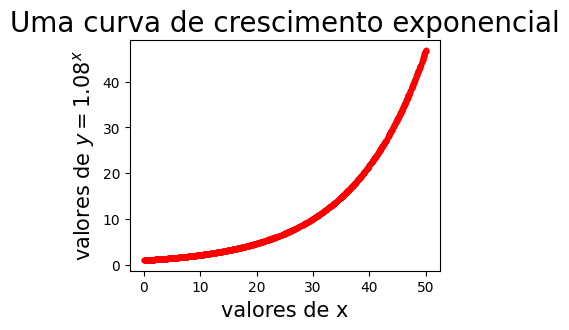

In [5]:
fig = plt.figure(dpi=100, figsize=(4, 3))                       # Cria uma nova figura com resolução de 100 dpi e tamanho 4x3 polegadas.
plt.plot(train_data[:,0], train_data[:,1], ".", c="r")          # Plota os pontos (x,y) em vermelho ("r"), no formato de dispersão (".").
plt.xlabel("valores de x", fontsize=15)                         # Define o rótulo do eixo x.
plt.ylabel("valores de $y=1.08^x$", fontsize=15)                # Define o rótulo do eixo y.
plt.title("Uma curva de crescimento exponencial", fontsize=20)  # Define o título do gráfico.
plt.show()                                                      # Exibe a figura.

## 1.2. Preparando o Conjunto de Treinamento

In [6]:
batch_size = 128                                 # Define o tamanho de cada mini-lote (quantidade de amostras processadas por iteração).
train_loader = DataLoader(                       # Cria o objeto DataLoader para organizar os dados de treinamento.
    train_data,                                  # Conjunto de dados a ser usado (nosso tensor com pares (x, y)).
    batch_size = batch_size,                     # Número de amostras por lote = 128.
    shuffle = True)                              # Embaralha os dados a cada época.

In [7]:
batch0 = next(iter(train_loader))                # Cria um iterador sobre o DataLoader e obtém o primeiro mini-lote de dados (128 amostras).

In [8]:
print(batch0)                                    # Exibe no console o conteúdo desse mini-lote (tensor com shape [128, 2]).

tensor([[41.9333, 25.2099],
        [ 8.0561,  1.8589],
        [22.2487,  5.5416],
        [49.9585, 46.7522],
        [ 8.7647,  1.9631],
        [ 3.0979,  1.2692],
        [26.0517,  7.4259],
        [38.2393, 18.9716],
        [37.1300, 17.4191],
        [45.0543, 32.0541],
        [ 8.7989,  1.9683],
        [20.4796,  4.8362],
        [46.7506, 36.5243],
        [21.8242,  5.3635],
        [11.2329,  2.3738],
        [40.3307, 22.2845],
        [47.0477, 37.3691],
        [47.6369, 39.1026],
        [16.2331,  3.4880],
        [11.7535,  2.4709],
        [12.8855,  2.6958],
        [20.6749,  4.9095],
        [ 4.6602,  1.4314],
        [26.3385,  7.5916],
        [31.7039, 11.4727],
        [45.5565, 33.3172],
        [41.3369, 24.0788],
        [26.8584,  7.9015],
        [14.9879,  3.1692],
        [33.7039, 13.3817],
        [47.7350, 39.3988],
        [31.7714, 11.5324],
        [ 7.4853,  1.7790],
        [14.5973,  3.0754],
        [31.4056, 11.2122],
        [35.8166, 15

In [9]:
print(batch0.shape)                              # Exibe no console o tamnho desse mini-lote (tensor com shape [128, 2]).

torch.Size([128, 2])


# 2. Criando Redes Adversárias Generativas (GANs)

## 2.1 Discriminador

In [10]:
import torch.nn as nn                                     # Importa o módulo nn, que contém blocos para construir redes neurais.

device = "cuda" if torch.cuda.is_available() else "cpu"   # Define o dispositivo de execução: usa GPU se disponível, caso contrário CPU.

D = nn.Sequential(                                        # Define o discriminador como uma rede sequencial (camadas empilhadas).
    nn.Linear(2, 256),                                    # Camada totalmente conectada: entrada com 2 features (x,y); saída com 256 neurônios.
    nn.ReLU(),                                            # Função de ativação ReLU.
    nn.Dropout(0.3),                                      # Dropout: desativa aleatoriamente 30% dos neurônios durante o treinamento.
    nn.Linear(256, 128),                                  # Camada linear: reduz de 256 para 128 neurônios.
    nn.ReLU(),                                            # Ativação ReLU.
    nn.Dropout(0.3),                                      # Dropout novamente (30%).
    nn.Linear(128, 64),                                   # Camada linear: reduz de 128 para 64 neurônios.
    nn.ReLU(),                                            # Ativação ReLU.
    nn.Dropout(0.3),                                      # Dropout novamente (30%).
    nn.Linear(64, 1),                                     # Camada final: reduz de 64 para 1 saída (probabilidade real/fake).
    nn.Sigmoid()                                          # Função sigmóide: comprime a saída para [0,1], interpretada como probabilidade.
).to(device)                                              # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [11]:
print(D)

Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=64, out_features=1, bias=True)
  (10): Sigmoid()
)


In [12]:
# Visualização com torchinfo
summary(D, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 256]                  768
├─ReLU: 1-2                              [1, 256]                  --
├─Dropout: 1-3                           [1, 256]                  --
├─Linear: 1-4                            [1, 128]                  32,896
├─ReLU: 1-5                              [1, 128]                  --
├─Dropout: 1-6                           [1, 128]                  --
├─Linear: 1-7                            [1, 64]                   8,256
├─ReLU: 1-8                              [1, 64]                   --
├─Dropout: 1-9                           [1, 64]                   --
├─Linear: 1-10                           [1, 1]                    65
├─Sigmoid: 1-11                          [1, 1]                    --
Total params: 41,985
Trainable params: 41,985
Non-trainable params: 0
Total m

## 2.2 Gerador

In [13]:
G = nn.Sequential(                               # Define o gerador como uma rede neural sequencial (camadas empilhadas).
    nn.Linear(2, 16),                            # Primeira camada linear: entrada com 2 dimensões (vetor de ruído); saída com 16 neurônios.
    nn.ReLU(),                                   # Função de ativação ReLU.
    nn.Linear(16, 32),                           # Segunda camada linear: expande de 16 para 32 neurônios.
    nn.ReLU(),                                   # Função de ativação ReLU.
    nn.Linear(32, 2)                             # Camada de saída: gera 2 valores (x, y) que simulam amostras reais.
).to(device)                                     # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [14]:
print(G)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


In [15]:
# Visualização com torchinfo
summary(G, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 2]                    --
├─Linear: 1-1                            [1, 16]                   48
├─ReLU: 1-2                              [1, 16]                   --
├─Linear: 1-3                            [1, 32]                   544
├─ReLU: 1-4                              [1, 32]                   --
├─Linear: 1-5                            [1, 2]                    66
Total params: 658
Trainable params: 658
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 2.3 Hiper-parâmetros

In [16]:
loss_fn = nn.BCELoss()                            # Define a função de perda: entropia cruzada binária [Binary Cross-Entropy, BCE]
lr = 0.0005                                       # Define a taxa de aprendizado [learning rate] para os otimizadores.
optimD = torch.optim.Adam(D.parameters(), lr=lr)  # Otimizador Adam para o discriminador D: ajusta seus pesos para melhorar a classificação real/falso.
optimG = torch.optim.Adam(G.parameters(), lr=lr)  # Otimizador Adam para o gerador G: ajusta seus pesos para "enganar" o discriminador.

## 2.4 Funções/classes utilitárias

In [17]:
mse = nn.MSELoss()                                # Define a função de perda: erro quadrático médio [Mean Squared Error, MSE], usada nesse exemplo para medir a diferença entre a curva real e os pontos gerados.
def performance(fake_samples):                    # Função para avaliar o desempenho do gerador.
    real = 1.08 ** fake_samples[:, 0]             # Calcula os valores "reais" de y = 1.08^x usando a 1a coluna (x) dos dados gerados.
    mseloss = mse(fake_samples[:, 1], real)       # Calcula o erro quadrático médio entre os y gerados (coluna 1) e os y reais.
    return mseloss                                # Retorna a métrica de desempenho (quanto menor, melhor).

In [18]:
class EarlyStop:                                         # Classe para implementar parada antecipada [early stopping] no treinamento.
    def __init__(self, patience=1000):                   # Construtor: recebe "patience" (número máximo de épocas sem melhora).
        self.patience = patience                         # Salva a paciência definida.
        self.steps = 0                                   # Contador de épocas consecutivas sem melhora.
        self.min_gdif = float('inf')                     # Melhor valor de erro (gdif) observado até agora (inicialmente infinito).

    def stop(self, gdif):                                # Método que decide se o treinamento deve parar, dado o valor atual da métrica gdif.
        if gdif < self.min_gdif:                         # Caso o valor atual seja melhor (menor) que o mínimo anterior:
            self.min_gdif = gdif                         # Atualiza o melhor valor observado.
            self.steps = 0                               # Reinicia o contador de épocas sem melhora.
        elif gdif >= self.min_gdif:                      # Caso contrário (não houve melhora):
            self.steps += 1                              # Incrementa o contador de épocas sem melhora.

        if self.steps >= self.patience:                  # Se o contador atingir o limite da paciência:
            return True                                  # sinaliza que é hora de parar o treinamento.
        else:
            return False                                 # Caso contrário, continua o treinamento normalmente.

stopper = EarlyStop()                                    # Cria um objeto EarlyStop com paciência padrão = 1000 épocas.

# 3. Treinar e Utilizar GANs para Geração de Formas

## 3.1 Treinar as GANs

In [19]:
real_labels = torch.ones((batch_size, 1))   # Cria um tensor de rótulos iguais a 1 (amostras reais), tamanho [batch_size, 1].
real_labels = real_labels.to(device)        # Move esse tensor para o dispositivo (CPU ou GPU).

fake_labels = torch.zeros((batch_size, 1))  # Cria um tensor de rótulos iguais a 0 (amostras falsas), tamanho [batch_size, 1].
fake_labels = fake_labels.to(device)        # Move esse tensor para o dispositivo (CPU ou GPU).

In [20]:
def train_D_on_real(real_samples):                  # Função para treinar o discriminador em dados reais.
    real_samples = real_samples.to(device)          # Move o lote de amostras reais para o dispositivo (CPU ou GPU).
    optimD.zero_grad()                              # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(real_samples)                         # Passa as amostras reais pelo discriminador: obtém probabilidades (saída).
    loss_D = loss_fn(out_D, real_labels)            # Calcula a perda comparando saída do discriminador com rótulos = 1 (reais).
    loss_D.backward()                               # Propaga os gradientes da perda para atualizar os pesos.
    optimD.step()                                   # Realiza a atualização dos pesos do discriminador (descida do gradiente).
    return loss_D                                   # Retorna o valor da perda para monitoramento.

In [21]:
def train_D_on_fake():                                # Função para treinar o discriminador em dados falsos (gerados pelo gerador G).
    noise = torch.randn((batch_size, 2))              # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2].
    noise = noise.to(device)                          # Move o ruído para o dispositivo (CPU ou GPU).
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    optimD.zero_grad()                                # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(fake_samples)                           # Passa as amostras falsas pelo discriminador: obtém probabilidades.
    loss_D = loss_fn(out_D, fake_labels)              # Calcula a perda comparando saída do discriminador com rótulos = 0 (falsos).
    loss_D.backward()                                 # Propaga os gradientes da perda para os parâmetros do discriminador.
    optimD.step()                                     # Atualiza os pesos do discriminador com base na perda calculada.
    return loss_D                                     # Retorna a perda para monitoramento.

In [22]:
def train_G():                                        # Função para treinar o gerador (G).
    noise = torch.randn((batch_size, 2))              # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2].
    noise = noise.to(device)                          # Move o ruído para o dispositivo (CPU ou GPU).
    optimG.zero_grad()                                # Zera os gradientes acumulados do otimizador do gerador.
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    out_G = D(fake_samples)                           # Passa as amostras falsas no discriminador: obtém probabilidades.
    loss_G = loss_fn(out_G, real_labels)              # Calcula a perda considerando rótulos = 1, POIS O GERADOR QUER QUE O DISCRIMINADOR CLASSIFIQUE AS AMOSTRAS FALSAS COMO REAIS.
    loss_G.backward()                                 # Propaga os gradientes da perda para os parâmetros do gerador.
    optimG.step()                                     # Atualiza os pesos do gerador (descida do gradiente).
    return loss_G, fake_samples                       # Retorna a perda e as amostras falsas geradas para análise/visualização.

In [23]:
os.makedirs("files", exist_ok=True)         # Cria a pasta "files" se ainda não existir, para salvar os gráficos gerados.

def test_epoch(epoch, gloss, dloss, n, fake_samples):         # Função para monitorar e visualizar o progresso do treino em certas épocas.
    if epoch == 0 or (epoch + 1) % 25 == 0:                   # Executa a cada 25 épocas, além da primeira (epoch = 0).
        g = gloss.item() / n                                  # Calcula a perda média do gerador dividindo pela quantidade de lotes.
        d = dloss.item() / n                                  # Calcula a perda média do discriminador.
        print(f"at epoch {epoch+1}, G loss: {g}, D loss {d}") # Imprime no console as perdas médias.

        fake = fake_samples.detach().cpu().numpy()                            # Converte as amostras falsas (do gerador) para NumPy (para visualização).
        plt.figure(dpi=100, figsize=(4, 3))                                   # Cria uma figura.

        plt.plot(fake[:,0], fake[:,1], "*", c="g", label="amostras geradas")  # Plota os pontos gerados em verde (simbolizados por asteriscos).
        plt.plot(train_data[:,0], train_data[:,1], ".", c="r", alpha=0.1, label="amostras reais") # Plota os dados reais em vermelho com transparência (alpha=0.1).

        plt.title(f"época {epoch+1}")                   # Define o título do gráfico indicando a época atual.
        plt.xlim(0, 50)                                 # Limita o eixo X entre 0 e 50 (mesma faixa dos dados reais).
        plt.ylim(0, 50)                                 # Limita o eixo Y entre 0 e 50.
        plt.legend()                                    # Exibe a legenda (diferencia amostras reais e geradas).
        plt.savefig(f"files/p{epoch+1}.png")            # Salva o gráfico na pasta "files" com nome correspondente à época.
        plt.show()                                      # Mostra a figura renderizada na tela.

at epoch 1, G loss: 0.7883047103881836, D loss 0.8404247919718425


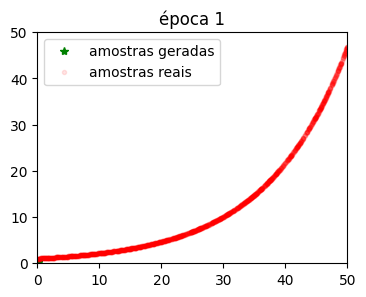

at epoch 25, G loss: 2.6178324381510416, D loss 0.4193332990010579


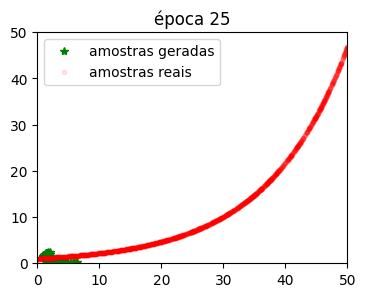

at epoch 50, G loss: 1.6095357259114584, D loss 0.8133878707885742


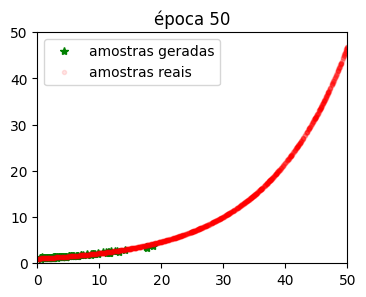

at epoch 75, G loss: 1.117851765950521, D loss 1.1110394795735676


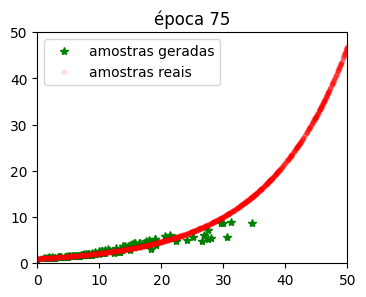

at epoch 100, G loss: 0.977528699239095, D loss 1.2181536356608074


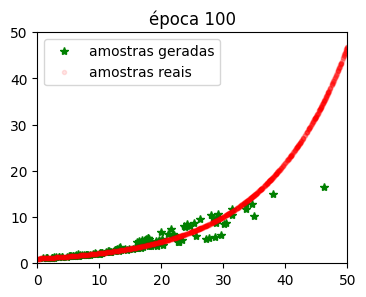

at epoch 125, G loss: 0.8838823318481446, D loss 1.329702631632487


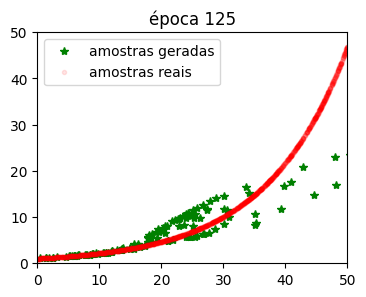

at epoch 150, G loss: 0.8406304041544597, D loss 1.3812129974365235


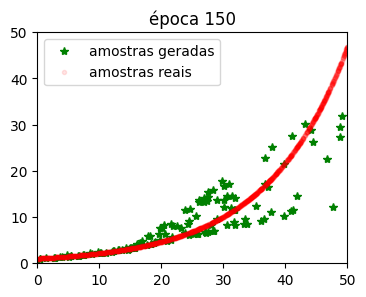

at epoch 175, G loss: 0.8155907313028972, D loss 1.440353012084961


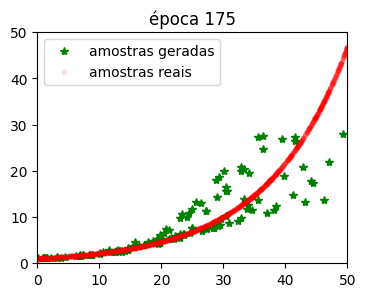

at epoch 200, G loss: 0.7918617248535156, D loss 1.4684548695882162


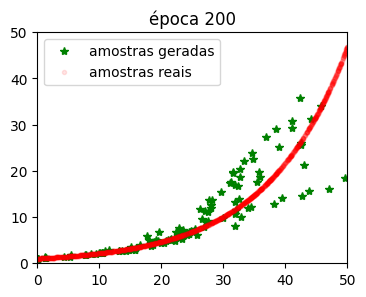

at epoch 225, G loss: 0.7745470682779948, D loss 1.4707939147949218


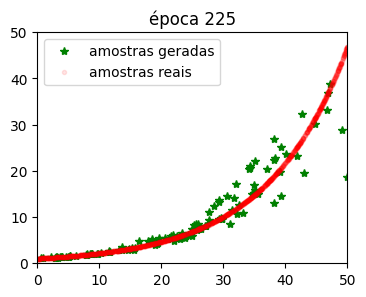

at epoch 250, G loss: 0.7764089584350586, D loss 1.4805557250976562


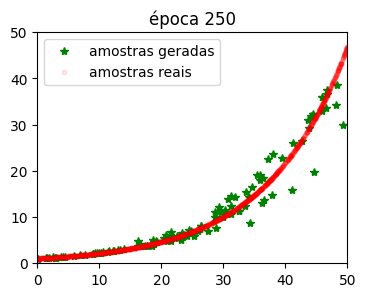

at epoch 275, G loss: 0.7669656117757161, D loss 1.478042221069336


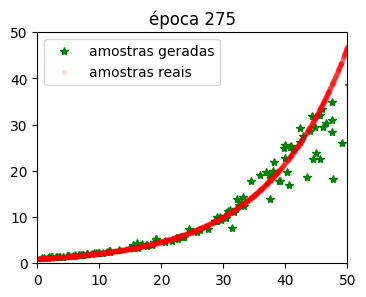

at epoch 300, G loss: 0.7598769505818684, D loss 1.4751598358154296


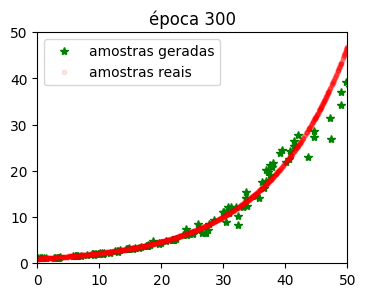

at epoch 325, G loss: 0.7587228139241536, D loss 1.4776907602945963


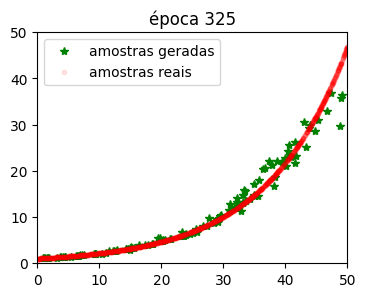

at epoch 350, G loss: 0.7651697158813476, D loss 1.4749371846516928


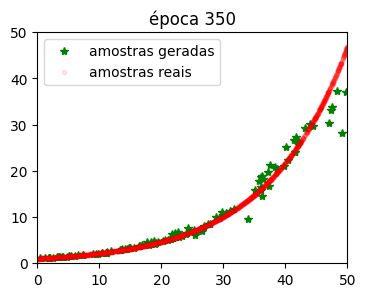

at epoch 375, G loss: 0.7602583567301432, D loss 1.4783496856689453


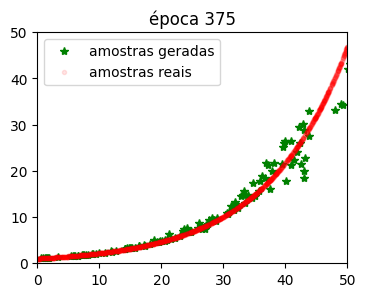

at epoch 400, G loss: 0.7530525843302409, D loss 1.4788633982340496


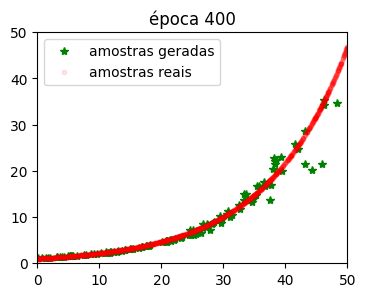

at epoch 425, G loss: 0.7435688018798828, D loss 1.4814937591552735


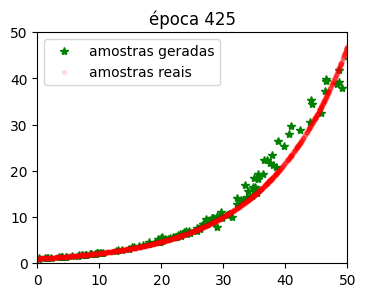

at epoch 450, G loss: 0.7516464233398438, D loss 1.4791755676269531


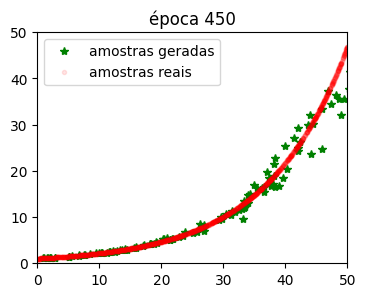

at epoch 475, G loss: 0.7541325251261394, D loss 1.4689585367838542


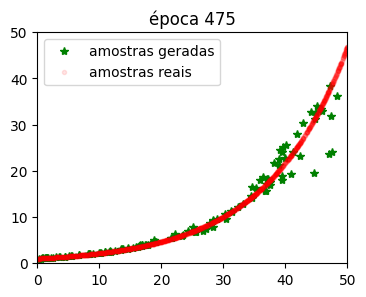

at epoch 500, G loss: 0.7519039789835612, D loss 1.4797936757405599


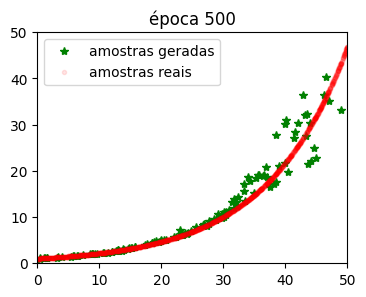

at epoch 525, G loss: 0.7454875946044922, D loss 1.4742488861083984


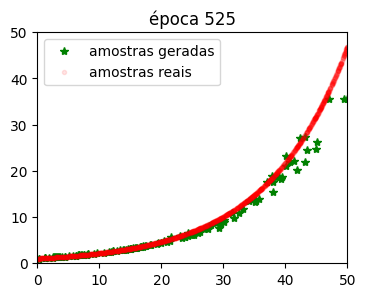

at epoch 550, G loss: 0.7515281041463217, D loss 1.4813910166422526


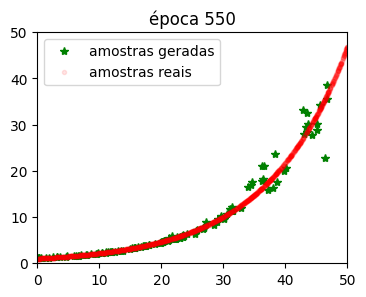

at epoch 575, G loss: 0.7485172271728515, D loss 1.4772491455078125


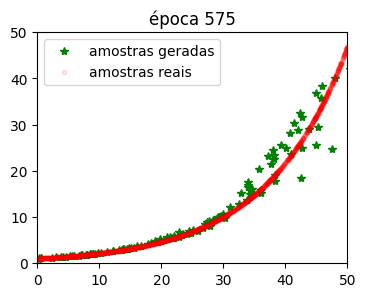

at epoch 600, G loss: 0.7480298995971679, D loss 1.479528299967448


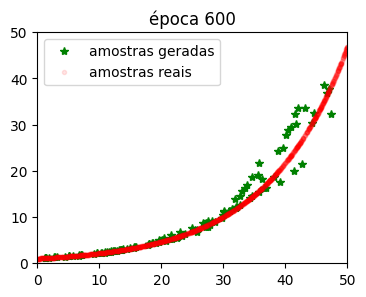

at epoch 625, G loss: 0.749462636311849, D loss 1.4772781372070312


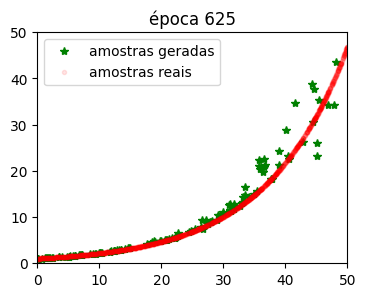

at epoch 650, G loss: 0.7478070576985677, D loss 1.4789031982421874


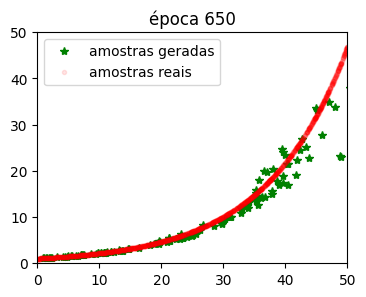

at epoch 675, G loss: 0.7509840647379558, D loss 1.4762954711914062


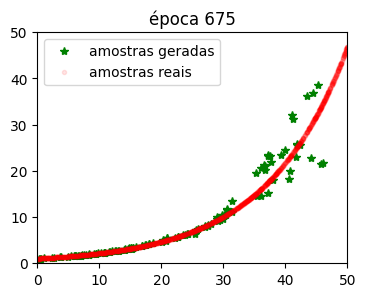

at epoch 700, G loss: 0.7481614430745442, D loss 1.4780471801757813


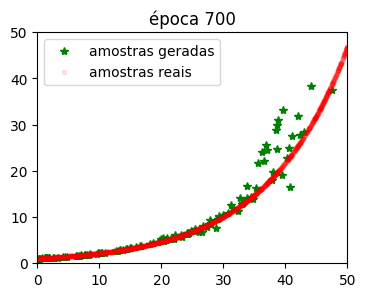

at epoch 725, G loss: 0.7540355046590169, D loss 1.4759560902913411


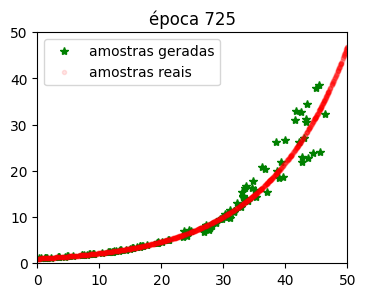

at epoch 750, G loss: 0.7542978286743164, D loss 1.4731076558430989


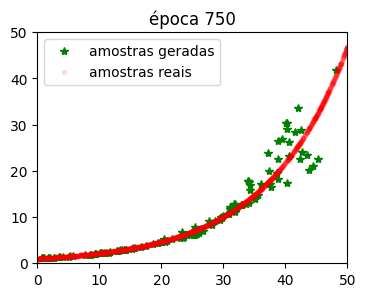

at epoch 775, G loss: 0.7494243621826172, D loss 1.476539103190104


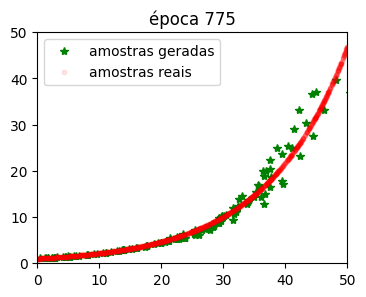

at epoch 800, G loss: 0.7533185958862305, D loss 1.4679139455159504


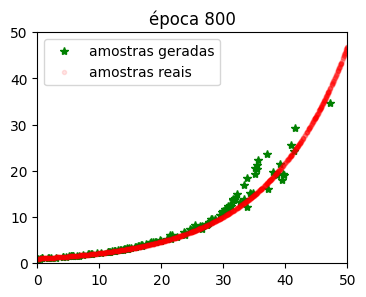

at epoch 825, G loss: 0.7391096750895182, D loss 1.458926010131836


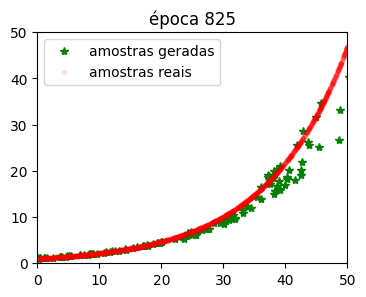

at epoch 850, G loss: 0.7508134841918945, D loss 1.4711755116780598


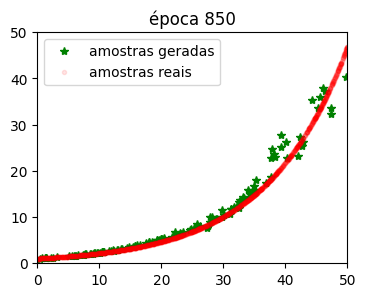

at epoch 875, G loss: 0.7588993072509765, D loss 1.471898651123047


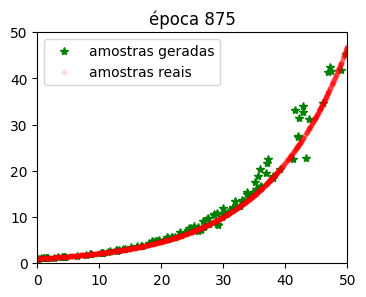

at epoch 900, G loss: 0.7553256988525391, D loss 1.4679515838623047


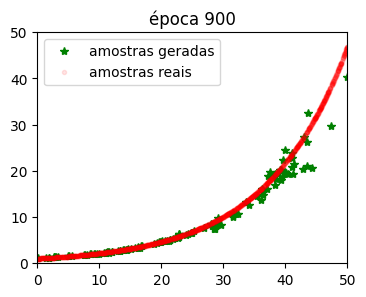

at epoch 925, G loss: 0.7517882029215495, D loss 1.4645531972249348


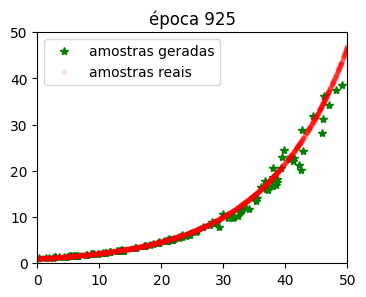

at epoch 950, G loss: 0.7479718526204427, D loss 1.4615179697672527


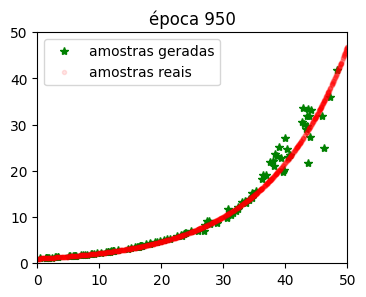

at epoch 975, G loss: 0.7649754206339519, D loss 1.4603499094645183


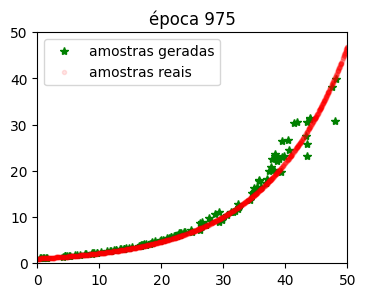

at epoch 1000, G loss: 0.7511199951171875, D loss 1.458425776163737


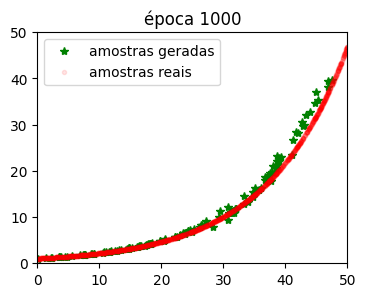

at epoch 1025, G loss: 0.7969290415445963, D loss 1.4395034790039063


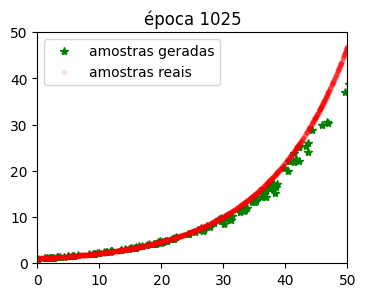

In [24]:
for epoch in range(10000):                        # Loop principal de treinamento do GAN (até 10.000 épocas no máximo).
    gloss = 0                                     # Inicializa acumulador da perda do gerador.
    dloss = 0                                     # Inicializa acumulador da perda do discriminador.

    for n, real_samples in enumerate(train_loader):   # Itera sobre os lotes do conjunto de treino.
        loss_D = train_D_on_real(real_samples)        # Treina o discriminador em amostras reais.
        dloss += loss_D                               # Acumula a perda do discriminador.
        loss_D = train_D_on_fake()                    # Treina o discriminador em amostras falsas (geradas).
        dloss += loss_D                               # Acumula novamente a perda do discriminador.
        loss_G, fake_samples = train_G()              # Treina o gerador e obtém as amostras falsas da iteração.
        gloss += loss_G                               # Acumula a perda do gerador.

    test_epoch(epoch, gloss, dloss, n, fake_samples)  # Exibe métricas e plota amostras (a cada 25 épocas ou na primeira).
    gdif = performance(fake_samples).item()           # Calcula a diferença (MSE) entre curva real e pontos gerados.
    if stopper.stop(gdif) == True:                    # Verifica se a condição de parada antecipada foi atingida.
        break                                         # Encerra o treinamento caso não haja melhora suficiente.

## 3.2 Salvar e utilizar o modelo treinado

In [25]:
scripted = torch.jit.script(G)                       # Converte o gerador (G) para o formato TorchScript.
scripted.save('files/exponential.pt')                # Salva o modelo convertido no arquivo "exponential.pt" dentro da pasta "files".

In [26]:
new_G = torch.jit.load('files/exponential.pt',       # Carrega o modelo salvo em TorchScript a partir do arquivo "exponential.pt".
                       map_location=device)          # Garante que o modelo seja carregado no dispositivo correto (CPU ou GPU).
new_G.eval()                                         # Coloca o modelo no modo de avaliação (desativa dropout, batchnorm em modo treino, etc.).

RecursiveScriptModule(
  original_name=Sequential
  (0): RecursiveScriptModule(original_name=Linear)
  (1): RecursiveScriptModule(original_name=ReLU)
  (2): RecursiveScriptModule(original_name=Linear)
  (3): RecursiveScriptModule(original_name=ReLU)
  (4): RecursiveScriptModule(original_name=Linear)
)

In [27]:
noise = torch.randn((batch_size, 2)).to(device)      # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2], e move para o dispositivo (CPU ou GPU).
new_data = new_G(noise)                              # Passa o ruído pelo gerador carregado (new_G): produz novas amostras falsas (x, y).

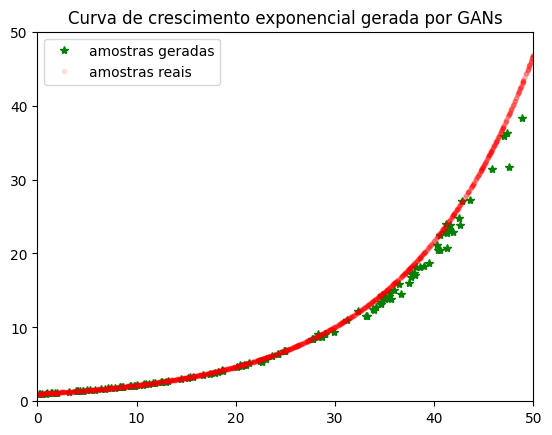

In [28]:
fig = plt.figure(dpi=100)                                       # Cria uma nova figura.

plt.plot(new_data.detach().cpu().numpy()[:,0],
         new_data.detach().cpu().numpy()[:,1], "*", c="g",
         label="amostras geradas")                              # Plota as amostras geradas em verde, usando marcador "*".

plt.plot(train_data[:,0], train_data[:,1], ".", c="r",
         alpha=0.1, label="amostras reais")                     # Plota as amostras reais em vermelho, com transparência (alpha=0.1).

plt.title("Curva de crescimento exponencial gerada por GANs")   # Define o título do gráfico.
plt.xlim(0, 50)                                                 # Limita o eixo X ao intervalo [0,50].
plt.ylim(0, 50)                                                 # Limita o eixo Y ao intervalo [0,50].
plt.legend()                                                    # Exibe a legenda (amostras reais vs. geradas).
plt.show()                                                      # Renderiza e exibe a figura.

# Tarefa (em duplas)

**Treinar uma GAN com o conjunto *Two Moons* do scikit-learn**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Gere o conjunto de dados *Two Moons* utilizando a função `make_moons` do [`scikit-learn`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html):

```python
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=4096, noise=0.1, random_state=42)
```

Obs.: lembre-se de normalizar os dados.

2. Substitua os dados de treinamento originais do código pelo conjunto *Two Moons*.  
3. Treine uma GAN (com gerador e discriminador definidos no código) para aprender a distribuição do *Two Moons* (se necessário faça mudanças nas arquiteturas das redes neurais). **Não utilize parada antecipada: treine a GAN por 1000 épocas.**
4. Registre a evolução das perdas do gerador e do discriminador ao longo do treinamento.  
5. Gere gráficos comparando os dados reais (*Two Moons*) e as amostras criadas pelo gerador em diferentes épocas.  
6. Salve o modelo treinado e mostre como carregar e gerar novas amostras a partir dele.  

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 1 — GANs**, que deve conter:

- **Setup**: dados utilizados (parâmetros de `make_moons` e normalização
  aplicada), arquiteturas do gerador e do discriminador, e hiperparâmetros
  (função de perda, otimizador, taxa de aprendizado, tamanho do lote, dimensão
  do vetor de ruído e número de épocas). Se alguma arquitetura ou hiperparâmetro
  do código base for alterado, registre a alteração explicitamente e justifique.
- **Resultados**:
  - curvas de perda do gerador e do discriminador ao longo das épocas;
  - gráficos comparando os dados reais e as amostras geradas em diferentes
    épocas do treinamento, incluindo o início, o meio e o final;
  - amostras geradas pelo modelo salvo e recarregado.
- **Análise**: texto breve (3-6 linhas) discutindo, a partir da inspeção visual
  das figuras, em que medida o gerador reproduziu a distribuição dos dados
  reais, e o que o comportamento das curvas de perda sugere sobre o
  treinamento.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.